# Meta Employee Retention & Engagement Analysis

## People Analytics Case Study | SQL + Python

### Business Context
This project analyzes a dataset of 7,500 employees from a Meta organizational psychology case study to address two workforce challenges:

1. **Top Performer Retention:** How can Meta identify and retain Top Performers fairly without simply raising wages?
2. **Employee Engagement:** How can Meta improve employee engagement, morale, and productivity?

### Analytical Approach
- **SQL:** Data validation, cleaning, and workforce-level aggregations
- **Python:** Employee segmentation, exploratory analysis, visualization, correlation, and regression
- **People Analytics:** Translate analytical findings into evidence-based workforce recommendations

## 1. Data Preparation

The dataset was first validated in SQL for missing values, duplicate employee records, variable ranges, and workforce-level patterns. Python was then used for the business-question-focused analysis below.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

df = pd.read_csv("/Users/prashastitripathi/Downloads/Meta dataset_2024.csv")

df.head()

,idnum,job,gender,ethnicity,tenure,age,salary,rating,job_sat,supv,turn,lead,net
0,6179,HR,female,white,3,30,102,1,1,3,5,2,4
1,1037,Sales_Mktg,male,asian,5,37,174,1,3,2,5,3,2
2,587,HR,female,asian,4,32,125,1,2,4,2,4,1
3,5987,SW_Dev,male,asian,1,30,166,1,4,3,2,2,1
4,2700,Acct_Fin,female,white,6,37,144,1,1,1,5,2,2


In [3]:
print("Dataset shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Dataset shape: (7500, 13)
Missing values: 0
Duplicate rows: 0


### Data Quality Summary

The dataset contains 7,500 employee records across 13 variables. No missing values or duplicate records were identified, so all observations were retained for analysis.

## 2. Business Question 1: Identifying and Retaining Top Performers

**Business Question:** How can Meta identify and retain Top Performers fairly without simply raising wages?

The analysis first identifies employees classified as Top Performers, examines their turnover intention, and then investigates whether the available employee characteristics and experience measures help explain retention risk.

In [4]:
df.groupby('rating')['turn'].mean()

rating
0    3.190476
1    3.217586
2    3.476314
Name: turn, dtype: float64

### Finding: Top Performer Retention Risk

Employees classified as Top Performers (rating = 2) had the highest average turnover intention (3.48), compared with employees who Met Expectations (3.22) or Needed Improvement (3.19).

This indicates that Top Performers are an important group for targeted retention analysis.

In [5]:
top_performers = df[df['rating'] == 2]

top_performers.shape

(1161, 13)

In [6]:
top_performers.groupby('job')['turn'].mean().sort_values(ascending=False)

job
SW_Dev        3.905579
Acct_Fin      3.316364
HR            3.134921
Sales_Mktg    3.091837
Name: turn, dtype: float64

### Finding: Highest-Risk Top Performer Group

Turnover intention was highest among Top Performers in Software Development (3.91), substantially higher than the other job groups. This identifies Software Development Top Performers as the primary retention-risk group in the dataset.

In [7]:
top_performers[['tenure', 'salary', 'job_sat', 'supv', 'lead', 'net', 'turn']].corr()['turn'].sort_values()

supv      -0.052883
tenure     0.005726
net        0.011349
lead       0.020385
job_sat    0.059631
salary     0.101758
turn       1.000000
Name: turn, dtype: float64

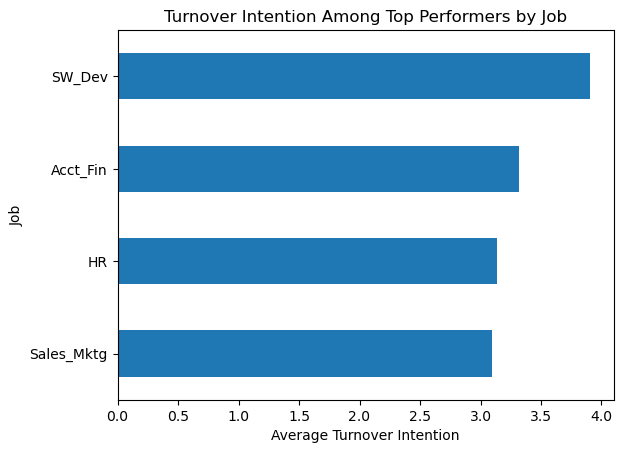

In [13]:
top_turnover = top_performers.groupby('job')['turn'].mean().sort_values()

top_turnover.plot(kind='barh')
plt.xlabel('Average Turnover Intention')
plt.ylabel('Job')
plt.title('Turnover Intention Among Top Performers by Job')
plt.show()

### Analysis of Potential Retention Drivers

Among Top Performers, turnover intention showed only weak correlations with the available employee characteristics and experience measures. Salary had the largest correlation with turnover intention (r = 0.10), but the relationship was still weak.

These results suggest that the available variables do not clearly explain why Top Performers report higher turnover intention.


### Regression Analysis

A multiple linear regression was used to examine whether the available employee characteristics and experience measures predict turnover intention across the full employee sample.

In [8]:
X = df[['tenure', 'salary', 'job_sat', 'supv', 'lead', 'age']]
y = df['turn']

X = sm.add_constant(X)

turnover_model = sm.OLS(y, X).fit()
turnover_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   turn   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.007
Date:                Tue, 08 Sep 2026   Prob (F-statistic):              0.418
Time:                        13:29:44   Log-Likelihood:                -12878.
No. Observations:                7500   AIC:                         2.577e+04
Df Residuals:                    7493   BIC:                         2.582e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.0910      0.138     22.402      0.000       2.821       3.361
tenure        -0.0020      0.007     -0.278      0.781      -0.016       0.012
salary         0.0004      0.000      1.144      0.252      -0.000       0.001
job_sat        0.0090      0.013      0.696      0.487      -0.016       0.034
supv          -0.0077      0.013     -0.585      0.558      -0.034       0.018
lead           0.0200      0.013      1.599      0.110      -0.005       0.045
age            0.0011      0.003      0.317      0.751      -0.006       0.008
==============================================================================
Omnibus:                    10565.309   Durbin-Watson:                   2.001
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              489.101
Skew:                          -0.053   Prob(JB):                    6.21e-107
Kurtosis:                       1.754   Cond. No.                     1.88e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.88e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Regression Finding

The regression model was not statistically significant (F-test p = 0.418) and explained only 0.1% of the variation in turnover intention (R² = 0.001).

None of the measured predictors—tenure, salary, job satisfaction, supervisor ratings, leadership ratings, or age—were statistically significant predictors of turnover intention.

This suggests that the available variables do not adequately explain why employees report higher turnover intention, reinforcing the need to investigate additional retention drivers.

### Business Recommendation

Top Performers should be prioritized for retention efforts, particularly those in Software Development, where average turnover intention was highest (3.91).

However, the analysis does not provide evidence that salary or the other measured factors are driving this risk. Rather than defaulting to compensation increases, Meta should conduct targeted diagnostic research with Software Development Top Performers, such as stay interviews or focused pulse surveys, to identify retention drivers not captured in the current dataset.

### Q1 Conclusion

The analysis identifies Software Development Top Performers as the highest-priority retention group, while also showing that additional data are needed before selecting a specific retention intervention.

## 3. Business Question 2: Improving Employee Engagement

**Business Question:** How can Meta improve employee engagement, morale, and productivity?

The analysis examines whether employee experience measures reveal specific groups or factors associated with lower engagement and morale.

In [9]:
df.groupby('job')['job_sat'].mean().sort_values()

job
HR            2.777333
Sales_Mktg    2.845867
Acct_Fin      2.853333
SW_Dev        2.890667
Name: job_sat, dtype: float64

### Job Satisfaction Finding

Average job satisfaction was similar across job groups, ranging from 2.78 to 2.89. This suggests that low job satisfaction is not concentrated within a particular job group.

In [10]:
df[['job_sat', 'supv', 'lead', 'net', 'turn']].corr()

,job_sat,supv,lead,net,turn
job_sat,1.000000,-0.014651,0.001986,-0.004025,0.008338
supv,-0.014651,1.000000,-0.013593,-0.001969,-0.009363
lead,0.001986,-0.013593,1.000000,0.001381,0.018458
net,-0.004025,-0.001969,0.001381,1.000000,0.000441
turn,0.008338,-0.009363,0.018458,0.000441,1.000000


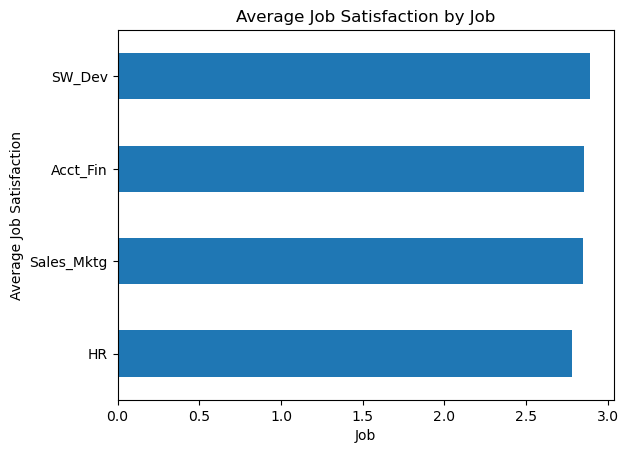

In [15]:
job_satisfaction = df.groupby('job')['job_sat'].mean().sort_values()

job_satisfaction.plot(kind='barh')
plt.ylabel('Average Job Satisfaction')
plt.xlabel('Job')
plt.title('Average Job Satisfaction by Job')
plt.show()

### Engagement Driver Finding

Job satisfaction, supervisor ratings, leadership ratings, net promoter scores, and turnover intention showed little to no correlation with one another.

The available measures therefore do not identify a clear factor associated with employee engagement or turnover intention.

### Business Recommendation

The current data does not support selecting a specific company-wide engagement intervention. Meta should first conduct targeted diagnostic research, such as employee interviews or focused pulse surveys, to identify factors contributing to low morale and engagement that are not captured in the current dataset.

### Q2 Conclusion

The analysis found no substantial differences in job satisfaction across job groups and no clear relationships among the available employee experience measures. Additional data are therefore needed to identify specific engagement drivers before designing targeted interventions.

## 4. Overall Findings

- Top Performers reported higher turnover intention than other performance groups.
- Software Development Top Performers showed the highest turnover intention (3.91), making them the clearest retention-risk group.
- The available employee characteristics and experience measures did not clearly explain turnover intention.
- Job satisfaction was similar across job groups, and the available engagement measures showed little relationship with one another.
- The analysis therefore identifies where retention risk is concentrated, but additional diagnostic data are needed to understand the underlying drivers.

## 5. Limitations

- The analysis is observational and does not establish causal relationships.
- Turnover intention represents employees' reported intention rather than actual employee turnover.
- The available variables may not capture important drivers of retention and engagement.
- Performance ratings identify existing Top Performers but do not provide enough information to evaluate whether the performance-rating process itself is fair.
- Productivity is not directly measured in the dataset, limiting conclusions about productivity outcomes.